In [17]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\chugh\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('ai4i2020.csv')

In [3]:
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values per column:")
print(df.isnull().sum())

Dataset Shape: (10000, 14)

Missing Values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [4]:
failure_counts = df['Machine failure'].value_counts()
normal_count = failure_counts[0]
failed_count = failure_counts[1]

In [5]:
print("\n--- Target Variable Distribution ---")
print(f"Normal Operations (0): {normal_count}")
print(f"Machine Failures (1): {failed_count}")
print(f"Failure Rate: {(failed_count / len(df)) * 100:.2f}%")


--- Target Variable Distribution ---
Normal Operations (0): 9661
Machine Failures (1): 339
Failure Rate: 3.39%


In [7]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})

In [8]:
sensor_data = df.drop(columns=['UDI', 'Product ID', 'Type', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

In [9]:
plt.figure(figsize=(10, 8))
correlation_matrix = sensor_data.corr()

<Figure size 1000x800 with 0 Axes>

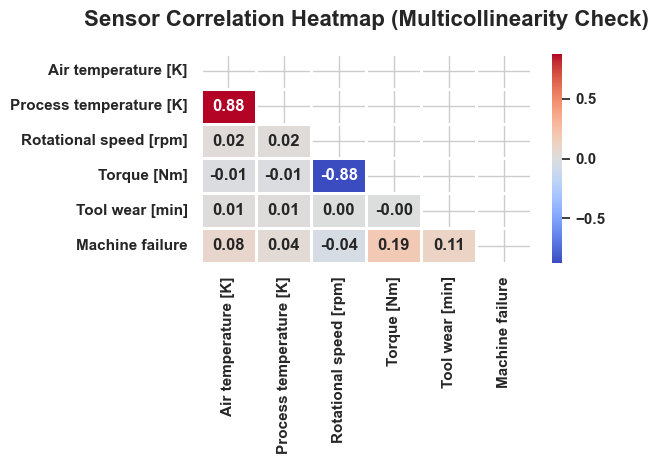

In [10]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, mask=np.triu(correlation_matrix)) 
plt.title("Sensor Correlation Heatmap (Multicollinearity Check)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

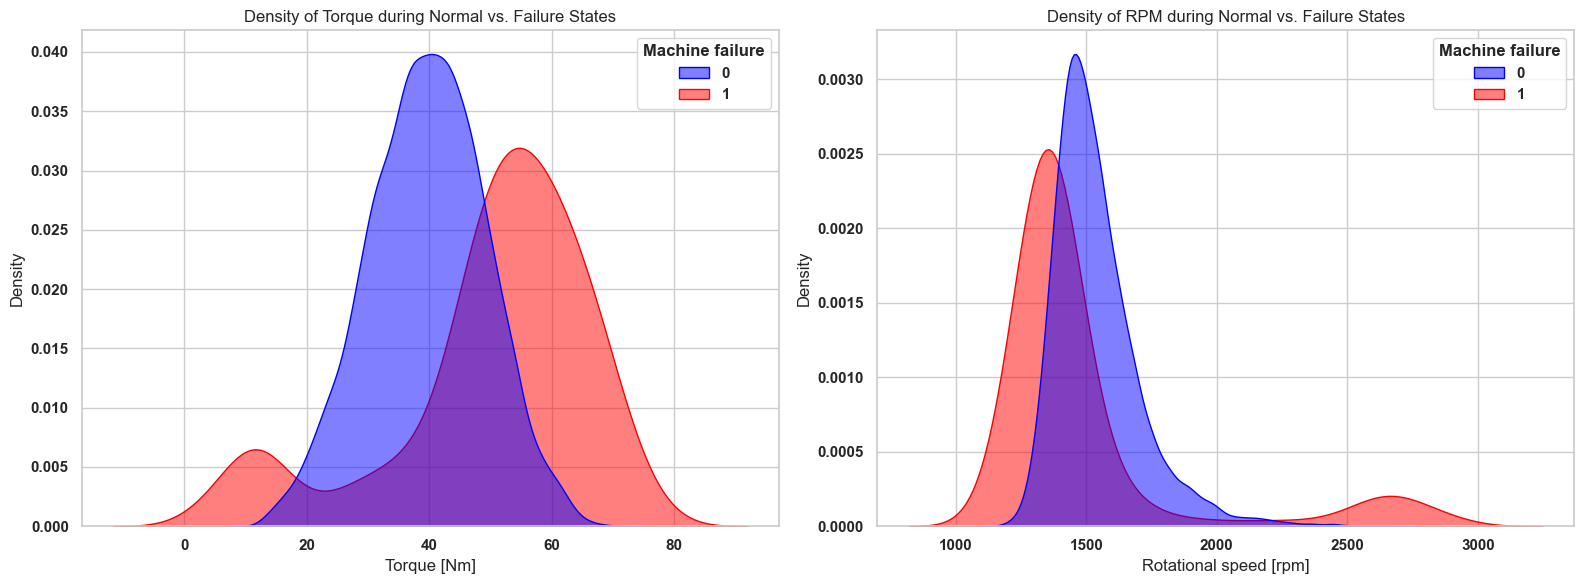

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Torque Distribution
sns.kdeplot(data=df, x="Torque [Nm]", hue="Machine failure", fill=True, 
            common_norm=False, palette={0: "blue", 1: "red"}, ax=axes[0], alpha=0.5)
axes[0].set_title("Density of Torque during Normal vs. Failure States")

# Plot 2: Rotational Speed Distribution
sns.kdeplot(data=df, x="Rotational speed [rpm]", hue="Machine failure", fill=True, 
            common_norm=False, palette={0: "blue", 1: "red"}, ax=axes[1], alpha=0.5)
axes[1].set_title("Density of RPM during Normal vs. Failure States")

plt.tight_layout()
plt.show()

In [19]:
# 1. Define Features (X) and Target (y)
# We drop ID columns, the specific failure types (since we are predicting general failure first), 
# AND we drop 'Process temperature' to solve the multicollinearity we found in the heatmap!
X = df.drop(columns=['UDI', 'Product ID', 'Type', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Process temperature [K]'])
y = df['Machine failure']

# 2. Train-Test Split FIRST to avoid Data Leakage
# We hold back 20% of the data to test the model on reality
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Apply SMOTE ONLY to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"--- Data Imbalance Fixed with SMOTE ---")
print(f"Before SMOTE (Training set): Normal = {sum(y_train==0)}, Failures = {sum(y_train==1)}")
print(f"After SMOTE (Training set): Normal = {sum(y_train_smote==0)}, Failures = {sum(y_train_smote==1)}\n")

# 4. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# 5. Predict on the unseen Test data
y_pred = rf_model.predict(X_test)

print("--- AI Model Performance ---")
print(classification_report(y_test, y_pred))

--- Data Imbalance Fixed with SMOTE ---
Before SMOTE (Training set): Normal = 7729, Failures = 271
After SMOTE (Training set): Normal = 7729, Failures = 7729

--- AI Model Performance ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.39      0.76      0.51        68

    accuracy                           0.95      2000
   macro avg       0.69      0.86      0.74      2000
weighted avg       0.97      0.95      0.96      2000



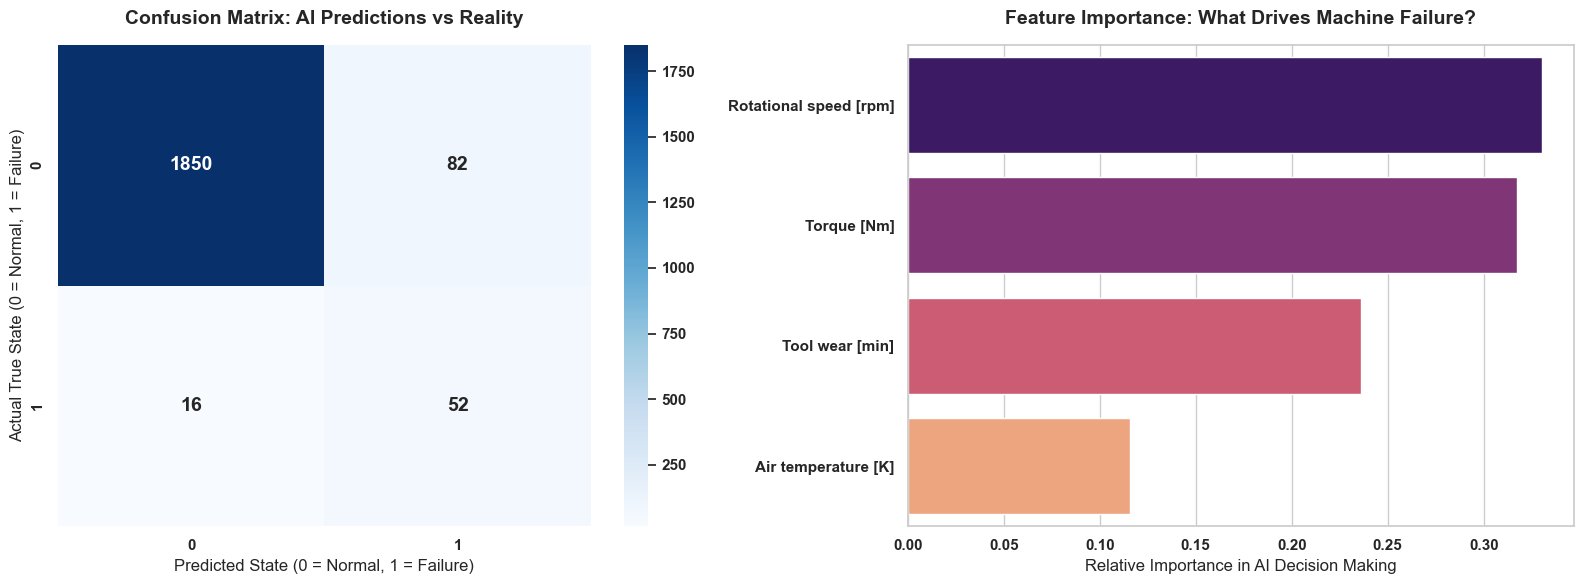

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# VISUAL 3: The Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix: AI Predictions vs Reality', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Predicted State (0 = Normal, 1 = Failure)')
axes[0].set_ylabel('Actual True State (0 = Normal, 1 = Failure)')

# ---------------------------------------------------------
# VISUAL 4: Explainable AI (Feature Importance)
# ---------------------------------------------------------
# Extracting the mathematical weights the Random Forest assigned to each sensor
importances = rf_model.feature_importances_
features = X.columns

# Create a DataFrame and sort it for a clean bar chart
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

sns.barplot(data=feature_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Feature Importance: What Drives Machine Failure?', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Relative Importance in AI Decision Making')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

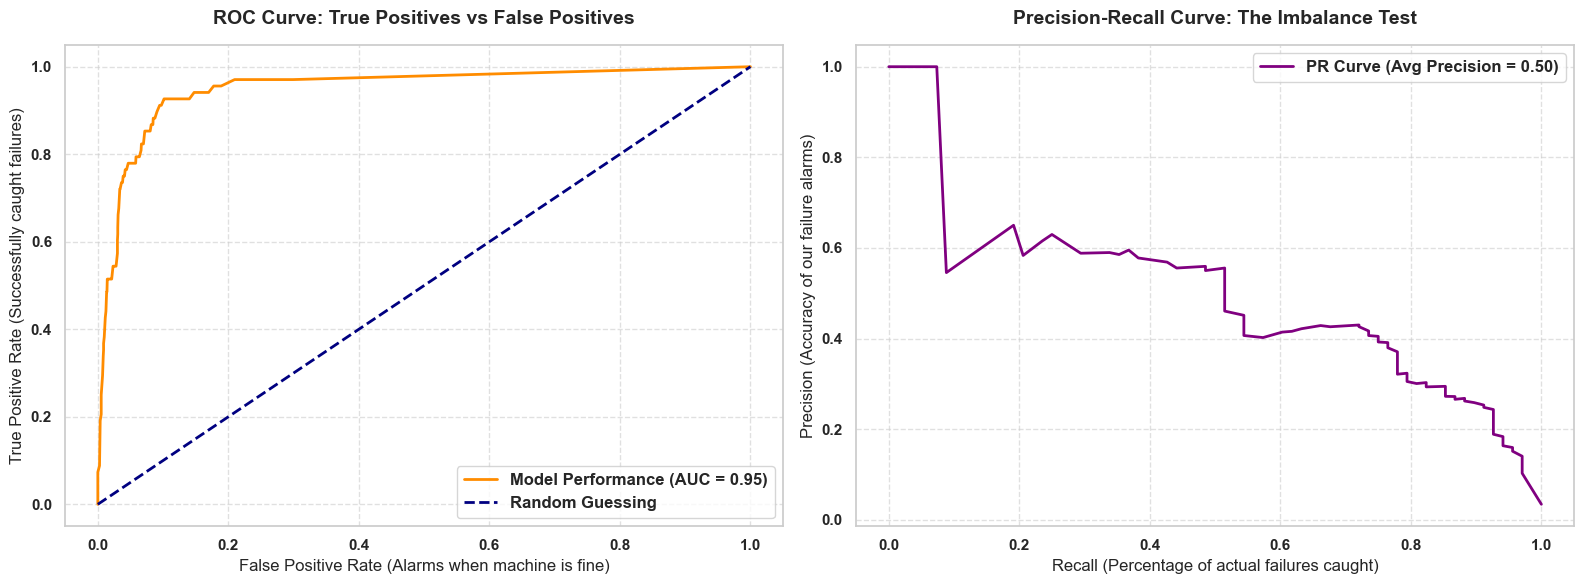

In [23]:
y_scores = rf_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# VISUAL 5A: Receiver Operating Characteristic (ROC) Curve
# ---------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Model Performance (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
axes[0].set_title('ROC Curve: True Positives vs False Positives', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('False Positive Rate (Alarms when machine is fine)')
axes[0].set_ylabel('True Positive Rate (Successfully caught failures)')
axes[0].legend(loc="lower right", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# VISUAL 5B: Precision-Recall (PR) Curve
# ---------------------------------------------------------
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR Curve (Avg Precision = {pr_auc:.2f})')
axes[1].set_title('Precision-Recall Curve: The Imbalance Test', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Recall (Percentage of actual failures caught)')
axes[1].set_ylabel('Precision (Accuracy of our failure alarms)')
axes[1].legend(loc="upper right", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()